In [1]:
import pandas as pd
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', None)

### EDA

In [2]:
child_df = pd.read_excel('data/CBDI3 All Evals for NSS.xlsx')
child_df.columns

Index(['Child ID', 'Gender', 'Date of Birth', 'Location - Sub Level 1',
       'contract number', 'Program Label', 'Adaptive Sum of Scaled Scores',
       'Adaptive Developmental Quotient', 'Adaptive Percentile Rank',
       'Adaptive 95% Confidence Interval', 'Adaptive RDI', 'Adaptive Z-Score',
       'Adaptive T-Score', 'Adaptive NCE',
       'Social-Emotional Sum of Scaled Scores',
       'Social-Emotional Developmental Quotient',
       'Social-Emotional Percentile Rank',
       'Social-Emotional 95% Confidence Interval', 'Social-Emotional RDI',
       'Social-Emotional Z-Score', 'Social-Emotional T-Score',
       'Social-Emotional NCE', 'Communication Sum of Scaled Scores',
       'Communication Developmental Quotient', 'Communication Percentile Rank',
       'Communication 95% Confidence Interval', 'Communication RDI',
       'Communication Z-Score', 'Communication T-Score', 'Communication NCE',
       'Motor Sum of Scaled Scores', 'Motor Developmental Quotient',
       'Motor Pe

In [3]:
child_df = (
    child_df.rename(columns={
        'Child ID': 'child_id',
        'Gender': 'gender',
        'Date of Birth': 'DOB',
        'Location - Sub Level 1': 'location_sublvl1',
        'contract number': 'contract_no',
        'Program Label': 'program_lbl'
    }).drop(columns=['Code 1', 'Code 2', 'Code 3','Code 4', 'Code 5', 'Code 6', 'Code 7', 'Code 8', 'Code 9', 'Code 10'])
)

child_df = child_df.drop_duplicates()

In [4]:
domains = {
    'Adaptive': ['Self Care', 'Personal Responsibility'],
    'Social-Emotional': ['Adult Interaction', 'Peer Interaction', 'Self Concept / Social Role'],
    'Communication': ['Receptive Communication', 'Expressive Communication'],
    'Motor': ['Gross Motor', 'Fine Motor', 'Perceptual Motor'],
    'Cognitive': ['Attention and Memory', 'Reasoning / Academic Skills', 'Perception and Concepts']
}

In [5]:
for dom in domains.keys():
    # Cleaning Domain Percentile Rank
    child_df[f'{dom} Percentile Rank'] = child_df[f'{dom} Percentile Rank'].replace('<0.1', 0.01)
    child_df[f'{dom} Percentile Rank'] = child_df[f'{dom} Percentile Rank'].replace('>99.9', 99.99)

    for s_dom in domains[dom]:
        dom_str = dom.replace('-', ' ')
        # Cleaning Sub-Domain Percentile Rank
        child_df[f'{dom_str}-{s_dom} PR'] = child_df[f'{dom_str}-{s_dom} PR'].replace('<1', 0.1)
        child_df[f'{dom_str}-{s_dom} PR'] = child_df[f'{dom_str}-{s_dom} PR'].replace('>99', 99.9)

        # Create Sub-Domain Ages
        child_df[f'{dom_str}-{s_dom} Testing Age'] = child_df[f'{dom_str}-{s_dom} Date of Testing'] - child_df['DOB']
    
    # Fixing incorrect RDI values
    child_df[f'{dom} RDI'] = child_df[f'{dom} RDI'].astype(str).str.replace(r'\d{4}-(\d{2})-.*',r'\1',regex=True)
    child_df[f'{dom} RDI'] = child_df[f'{dom} RDI'].str.replace(r'^(\d{2})$',r'\1/90',regex=True)

child_df['BDI-3 Total Percentile Rank'] = child_df['BDI-3 Total Percentile Rank'].replace('<0.1', 0.01)
child_df['BDI-3 Total Percentile Rank'] = child_df['BDI-3 Total Percentile Rank'].replace('>99.9', 99.99)

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/2779423171.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  child_df[f'{dom} Percentile Rank'] = child_df[f'{dom} Percentile Rank'].replace('<0.1', 0.01)
/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/2779423171.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  child_df[f'{dom_str}-{s_dom} PR'] = child_df[f'{dom_str}-{s_dom} PR'].replace('>99', 99.9)
/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/2779423171.py:10: FutureWarni

### 1. In which domains (and sub-domains) are children performing highest and lowest?

In [6]:
import re
import seaborn as sns
import matplotlib.pyplot as plt

columns = child_df.columns.tolist()

In [7]:
domPR_col = [col for col in columns if re.match(r'.*Percentile Rank', col)]
domPR_df = child_df[['child_id'] + domPR_col]

domPR_col = list(domains.keys())
for dom in domains.keys():
    domPR_df = domPR_df.rename(columns = {f'{dom} Percentile Rank': f'{dom}'})

domPR_df = domPR_df.rename(columns = {'BDI-3 Total Percentile Rank': 'BDI-3 Total'})

In [8]:
domPR_df = domPR_df.groupby('child_id').max()

In [9]:
domPR_df

,Adaptive,Social-Emotional,Communication,Motor,Cognitive,BDI-3 Total
child_id,,,,,,
44879,16.0,96.0,27.0,21.0,50.0,47.0
47795,21.0,61.0,42.0,55.0,50.0,47.0
54340,25.0,27.0,12.0,73.0,13.0,23.0
54344,84.0,58.0,21.0,27.0,81.0,53.0
54515,5.0,4.0,2.0,4.0,42.0,3.0
...,...,...,...,...,...,...
SP03287,84.0,84.0,79.0,88.0,81.0,90.0
SP03288,84.0,86.0,79.0,87.0,93.0,90.0
SP03289,58.0,55.0,0.1,61.0,45.0,34.0


In [10]:
colormap = {
    'Adaptive': '#4c72b0',
    'Social-Emotional': '#dd8452',
    'Communication': '#55a868',
    'Motor': '#c44e52',
    'Cognitive': '#8172b3'
}

<Axes: >

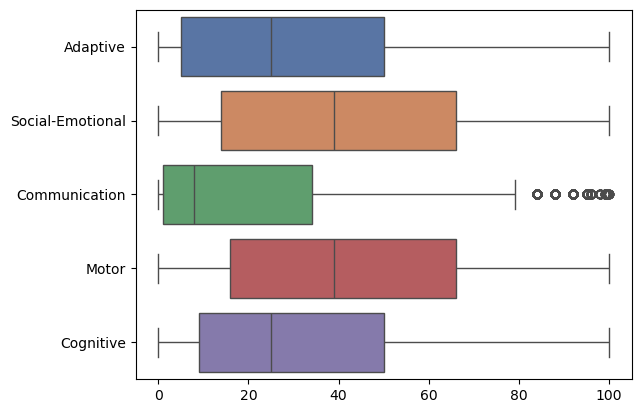

In [11]:
sns.boxplot(domPR_df[domPR_col], orient='h', palette=colormap)

In [12]:
subdomPR_col = [col for col in columns if re.match(r'.*PR', col)]
subdomPR_df = child_df[['child_id'] + subdomPR_col + ['BDI-3 Total Percentile Rank']]

subdomPR_col = [re.sub(r'\sPR$', '', col) for col in subdomPR_col]
subdomPR_df.columns = ['child_id'] + subdomPR_col + ['BDI-3 Total']

In [13]:
subdomPR_df = subdomPR_df.groupby('child_id').mean()

In [14]:
subcolormap = {}
for col in subdomPR_df.columns:
    for dom, color in colormap.items():
        dom_str = dom.replace('-', ' ')
        if re.match(rf'^{dom_str}.*', col):
            subcolormap[col] = color

In [15]:
subcolormap

{'Adaptive-Self Care': '#4c72b0',
 'Adaptive-Personal Responsibility': '#4c72b0',
 'Social Emotional-Adult Interaction': '#dd8452',
 'Social Emotional-Peer Interaction': '#dd8452',
 'Social Emotional-Self Concept / Social Role': '#dd8452',
 'Communication-Receptive Communication': '#55a868',
 'Communication-Expressive Communication': '#55a868',
 'Motor-Gross Motor': '#c44e52',
 'Motor-Fine Motor': '#c44e52',
 'Motor-Perceptual Motor': '#c44e52',
 'Cognitive-Attention and Memory': '#8172b3',
 'Cognitive-Reasoning / Academic Skills': '#8172b3',
 'Cognitive-Perception and Concepts': '#8172b3'}

<Axes: >

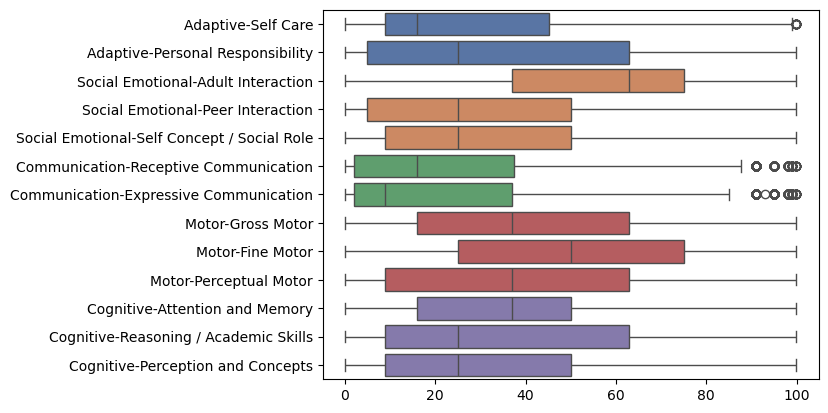

In [16]:
sns.boxplot(subdomPR_df[subdomPR_col], orient='h',palette=subcolormap)

**Follow up notes:**
- Grouping the dataframe by child ID to see how the summary statistics change

### 2. What is the pattern of children's scores? Do individual children tend to perform similarly across all domains or are there differences from domain to domain? Are these patterns similar for all children?

In [17]:
domPR_df[domPR_col].corr()

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
Adaptive,1.000000,0.555225,0.463812,0.492640,0.475237
Social-Emotional,0.555225,1.000000,0.519299,0.461759,0.594271
Communication,0.463812,0.519299,1.000000,0.404886,0.652000
Motor,0.492640,0.461759,0.404886,1.000000,0.523688
Cognitive,0.475237,0.594271,0.652000,0.523688,1.000000


In [156]:
domPR_df['scoring_group'] = pd.qcut(
    domPR_df['BDI-3 Total'], 
    4, 
    labels=['Bottom','Lower-Middle','Upper-Middle','Top'])

In [157]:
domPR_df.groupby('scoring_group').corr()

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/1252639832.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  domPR_df.groupby('scoring_group').corr()


Adaptive  Social-Emotional  Communication  \
scoring_group                                                               
Bottom        Adaptive          1.000000          0.131211       0.030650   
              Social-Emotional  0.131211          1.000000       0.076495   
              Communication     0.030650          0.076495       1.000000   
              Motor             0.190180         -0.063196      -0.033355   
              Cognitive         0.020881          0.101510       0.150164   
              BDI-3 Total       0.350364          0.453772       0.277445   
Lower-Middle  Adaptive          1.000000          0.027070      -0.156684   
              Social-Emotional  0.027070          1.000000      -0.060844   
              Communication    -0.156684         -0.060844       1.000000   
              Motor            -0.021017         -0.302490      -0.277272   
              Cognitive        -0.224943         -0.119355       0.133434   
              BDI-3 Total       0.218678          0.283728       0.230810   
Upper-Middle  Adaptive          1.000000         -0.010470      -0.192686   
              Social-Emotional -0.010470          1.000000      -0.188897   
              Communication    -0.192686         -0.188897       1.000000   
              Motor            -0.082300         -0.281842      -0.338084   
              Cognitive        -0.250131         -0.143602       0.107304   
              BDI-3 Total       0.205359          0.240444       0.269229   
Top           Adaptive          1.000000          0.081204       0.013045   
              Social-Emotional  0.081204          1.000000      -0.015250   
              Communication     0.013045         -0.015250       1.000000   
              Motor             0.057524         -0.080628      -0.090747   
              Cognitive        -0.080763          0.096112       0.280119   
              BDI-3 Total       0.341021          0.465638       0.528671   

                                   Motor  Cognitive  BDI-3 Total  
scoring_group                                                     
Bottom        Adaptive          0.190180   0.020881     0.350364  
              Social-Emotional -0.063196   0.101510     0.453772  
              Communication    -0.033355   0.150164     0.277445  
              Motor             1.000000   0.170644     0.467104  
              Cognitive         0.170644   1.000000     0.512075  
              BDI-3 Total       0.467104   0.512075     1.000000  
Lower-Middle  Adaptive         -0.021017  -0.224943     0.218678  
              Social-Emotional -0.302490  -0.119355     0.283728  
              Communication    -0.277272   0.133434     0.230810  
              Motor             1.000000  -0.102229     0.263185  
              Cognitive        -0.102229   1.000000     0.287422  
              BDI-3 Total       0.263185   0.287422     1.000000  
Upper-Middle  Adaptive         -0.082300  -0.250131     0.205359  
              Social-Emotional -0.281842  -0.143602     0.240444  
              Communication    -0.338084   0.107304     0.269229  
              Motor             1.000000  -0.182270     0.204617  
              Cognitive        -0.182270   1.000000     0.257181  
              BDI-3 Total       0.204617   0.257181     1.000000  
Top           Adaptive          0.057524  -0.080763     0.341021  
              Social-Emotional -0.080628   0.096112     0.465638  
              Communication    -0.090747   0.280119     0.528671  
              Motor             1.000000  -0.011947     0.375935  
              Cognitive        -0.011947   1.000000     0.536696  
              BDI-3 Total       0.375935   0.536696     1.000000

<Axes: xlabel='Cognitive', ylabel='Communication'>

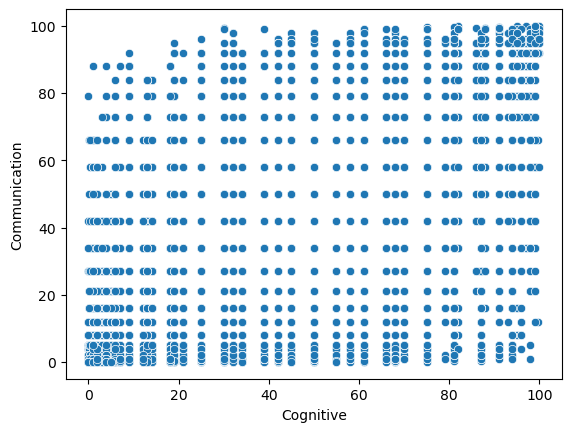

In [20]:
sns.scatterplot(domPR_df, x='Cognitive', y='Communication')

In [21]:
bottom_df = domPR_df.loc[domPR_df['scoring_group'] == 'Bottom']
lowmid_df = domPR_df.loc[domPR_df['scoring_group'] == 'Lower-Middle']
uppmid_df = domPR_df.loc[domPR_df['scoring_group'] == 'Upper-Middle']
top_df = domPR_df.loc[domPR_df['scoring_group'] == 'Top']

<Axes: >

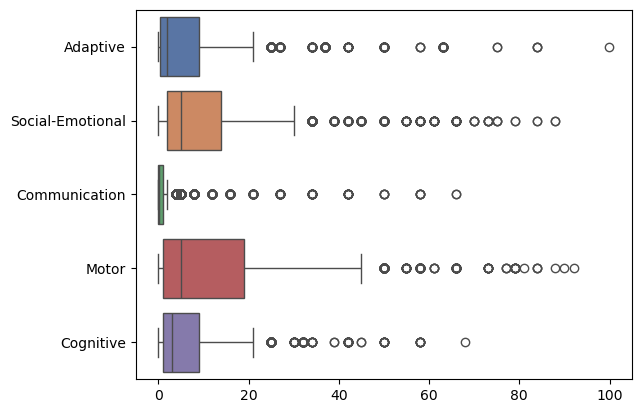

In [22]:
sns.boxplot(bottom_df[domPR_col], orient='h', palette=colormap)

<Axes: >

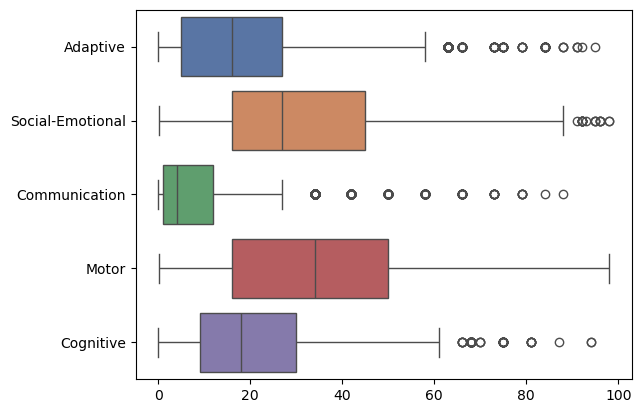

In [23]:
sns.boxplot(lowmid_df[domPR_col], orient='h', palette=colormap)

<Axes: >

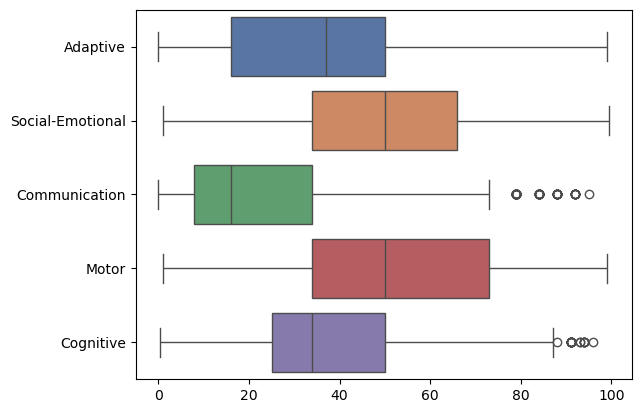

In [24]:
sns.boxplot(uppmid_df[domPR_col], orient='h', palette=colormap)

<Axes: >

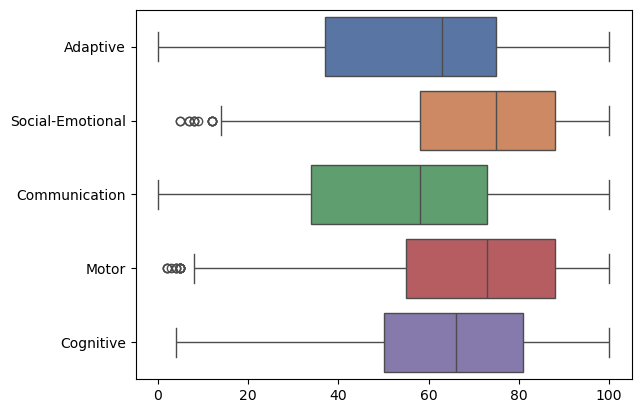

In [25]:
sns.boxplot(top_df[domPR_col], orient='h', palette=colormap)

In [26]:
domPR_df.groupby('scoring_group').describe()

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/4066920061.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  domPR_df.groupby('scoring_group').describe()


Adaptive                                                      \
                 count       mean        std   min   25%   50%   75%   max   
scoring_group                                                                
Bottom          4786.0   7.081860  10.850383  0.01   0.3   2.0   9.0  99.9   
Lower-Middle    4914.0  20.228848  17.890647  0.01   5.0  16.0  27.0  95.0   
Upper-Middle    4560.0  36.720090  22.626987  0.01  16.0  37.0  50.0  99.0   
Top             4716.0  57.533333  24.434649  0.10  37.0  63.0  75.0  99.9   

              Social-Emotional                                                \
                         count       mean        std   min   25%   50%   75%   
scoring_group                                                                  
Bottom                  4786.0  10.605629  12.907791  0.01   2.0   5.0  14.0   
Lower-Middle            4914.0  31.618844  19.717145  0.20  16.0  27.0  45.0   
Upper-Middle            4560.0  50.337390  20.966712  1.00  34.0  50.0  66.0   
Top                     4716.0  72.396211  19.916635  5.00  58.0  75.0  88.0   

                     Communication                                           \
                 max         count       mean        std   min    25%   50%   
scoring_group                                                                 
Bottom         88.00        4786.0   1.946350   5.378884  0.01   0.01   0.1   
Lower-Middle   98.00        4914.0   9.561893  12.957401  0.01   1.00   4.0   
Upper-Middle   99.50        4560.0  23.589656  20.036437  0.01   8.00  16.0   
Top            99.99        4716.0  53.191809  26.670493  0.10  34.00  58.0   

                             Motor                                          \
                75%    max   count       mean        std   min   25%   50%   
scoring_group                                                                
Bottom          1.0  66.00  4786.0  12.513456  15.111476  0.01   1.0   5.0   
Lower-Middle   12.0  88.00  4914.0  34.939235  21.506508  0.10  16.0  34.0   
Upper-Middle   34.0  95.00  4560.0  51.526974  23.205202  1.00  34.0  50.0   
Top            73.0  99.99  4716.0  69.811399  22.451637  2.00  55.0  73.0   

                           Cognitive                                          \
                75%    max     count       mean        std   min   25%   50%   
scoring_group                                                                  
Bottom         19.0  92.00    4786.0   5.844662   7.812624  0.01   1.0   3.0   
Lower-Middle   50.0  98.00    4914.0  21.512501  15.065297  0.01   9.0  18.0   
Upper-Middle   73.0  99.00    4560.0  37.822237  18.731058  0.40  25.0  34.0   
Top            88.0  99.99    4716.0  62.736533  21.475059  4.00  50.0  66.0   

                           BDI-3 Total                                     \
                75%    max       count       mean        std    min   25%   
scoring_group                                                               
Bottom          9.0  68.00      4786.0   2.204530   1.927197   0.01   0.4   
Lower-Middle   30.0  94.00      4914.0  14.616402   4.961236   7.00  10.0   
Upper-Middle   50.0  96.00      4560.0  35.738596   6.968113  25.00  30.0   
Top            81.0  99.99      4716.0  68.859218  13.424479  50.00  58.0   

                                  
                50%   75%    max  
scoring_group                     
Bottom          2.0   4.0   6.00  
Lower-Middle   14.0  19.0  23.00  
Upper-Middle   35.5  42.0  47.00  
Top            66.0  79.0  99.99

### 3. Is there a pattern of significant differences in children's scores in the sub-domains within a domain? For example, a gap between a child's expressive (talking) and receptive (understanding) language scores may indicate that additional evaluation is needed for that child's eligibility. A gap between these sub-domains for all or most children may indicate the BDI-3 tool may lack sensitivity in the language domain.

In [45]:
import numpy as np

In [27]:
subdomPR_df['scoring_group'] = pd.qcut(
    subdomPR_df['BDI-3 Total'], 
    3, 
    labels=['Bottom','Middle','Top'])

In [28]:
sbottom_df = subdomPR_df.loc[subdomPR_df['scoring_group'] == 'Bottom']
smid_df = subdomPR_df.loc[subdomPR_df['scoring_group'] == 'Middle']
stop_df = subdomPR_df.loc[subdomPR_df['scoring_group'] == 'Top']

In [29]:
subdomPR_df[subdomPR_col].corr()

,Adaptive-Self Care,Adaptive-Personal Responsibility,Social Emotional-Adult Interaction,Social Emotional-Peer Interaction,Social Emotional-Self Concept / Social Role,Communication-Receptive Communication,Communication-Expressive Communication,Motor-Gross Motor,Motor-Fine Motor,Motor-Perceptual Motor,Cognitive-Attention and Memory,Cognitive-Reasoning / Academic Skills,Cognitive-Perception and Concepts
Adaptive-Self Care,1.000000,0.495520,0.382289,0.453601,0.450442,0.443241,0.401842,0.342698,0.446704,0.414613,0.388417,0.386699,0.422204
Adaptive-Personal Responsibility,0.495520,1.000000,0.599279,0.569519,0.585859,0.443958,0.382054,0.425444,0.417851,0.383053,0.417289,0.443263,0.403694
Social Emotional-Adult Interaction,0.382289,0.599279,1.000000,0.629574,0.561334,0.393512,0.334148,0.352451,0.456047,0.458311,0.487952,0.494879,0.401179
Social Emotional-Peer Interaction,0.453601,0.569519,0.629574,1.000000,0.619614,0.422219,0.373121,0.400576,0.409141,0.354977,0.397841,0.411896,0.365215
Social Emotional-Self Concept / Social Role,0.450442,0.585859,0.561334,0.619614,1.000000,0.507201,0.500548,0.257282,0.380907,0.431417,0.487110,0.520963,0.482909
Communication-Receptive Communication,0.443241,0.443958,0.393512,0.422219,0.507201,1.000000,0.636082,0.285160,0.441594,0.530048,0.486678,0.597144,0.610169
Communication-Expressive Communication,0.401842,0.382054,0.334148,0.373121,0.500548,0.636082,1.000000,0.177780,0.339401,0.419424,0.454762,0.524556,0.567690
Motor-Gross Motor,0.342698,0.425444,0.352451,0.400576,0.257282,0.285160,0.177780,1.000000,0.459275,0.429629,0.308341,0.422714,0.286584
Motor-Fine Motor,0.446704,0.417851,0.456047,0.409141,0.380907,0.441594,0.339401,0.459275,1.000000,0.588058,0.469081,0.545731,0.449975
Motor-Perceptual Motor,0.414613,0.383053,0.458311,0.354977,0.431417,0.530048,0.419424,0.429629,0.588058,1.000000,0.522834,0.518338,0.544725


#### Scoring Group: **Bottom**

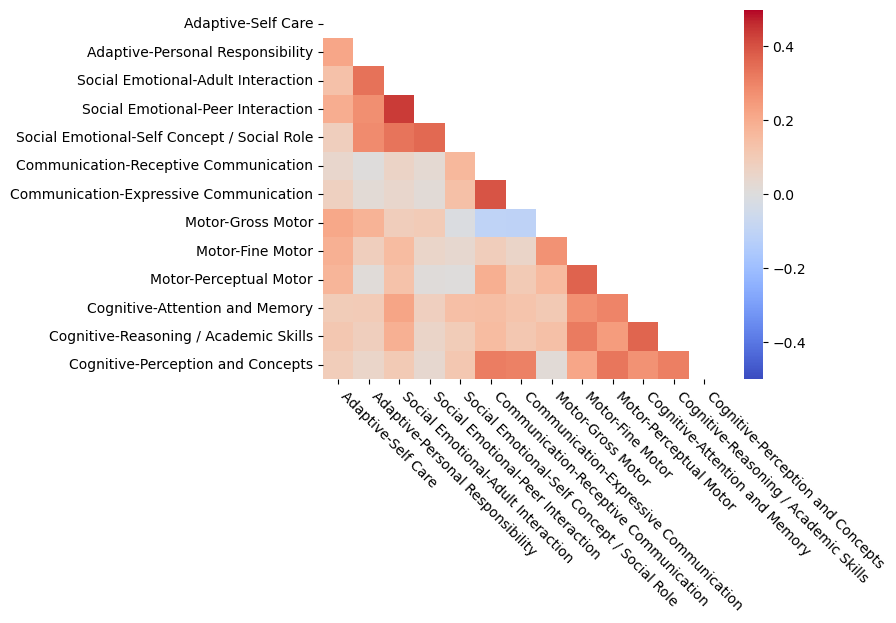

In [46]:
corr_mtx = sbottom_df[subdomPR_col].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=0.5, vmin=-0.5, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

<Axes: >

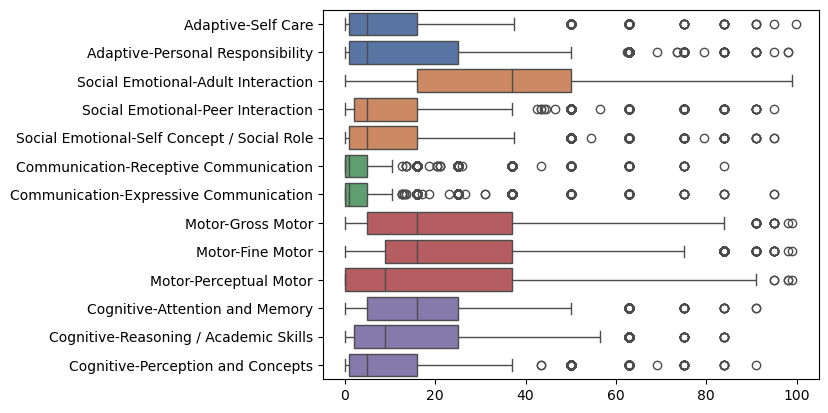

In [35]:
sns.boxplot(sbottom_df[subdomPR_col], orient='h', palette=subcolormap)

#### Scoring Group: **Middle**

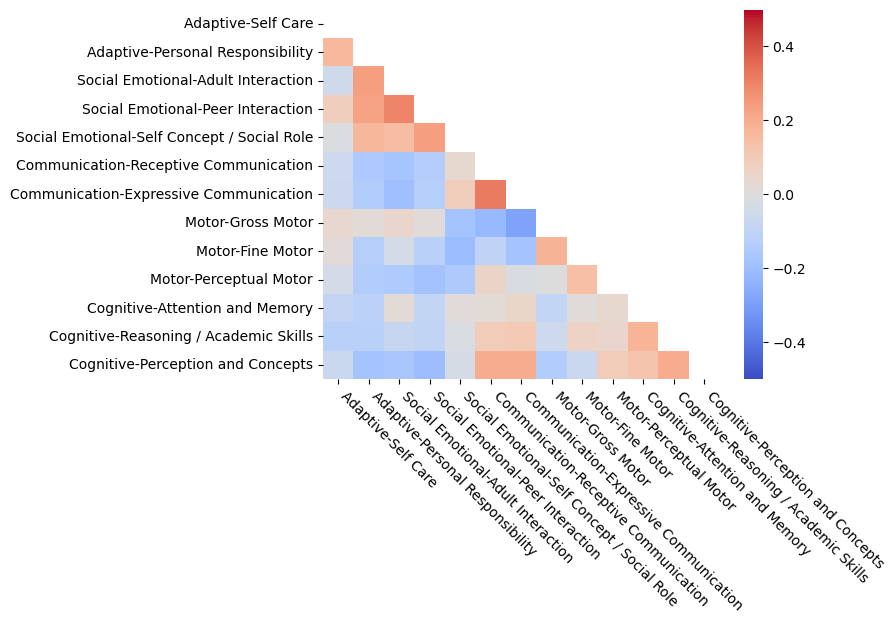

In [55]:
corr_mtx = smid_df[subdomPR_col].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=0.5, vmin=-0.5, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

<Axes: >

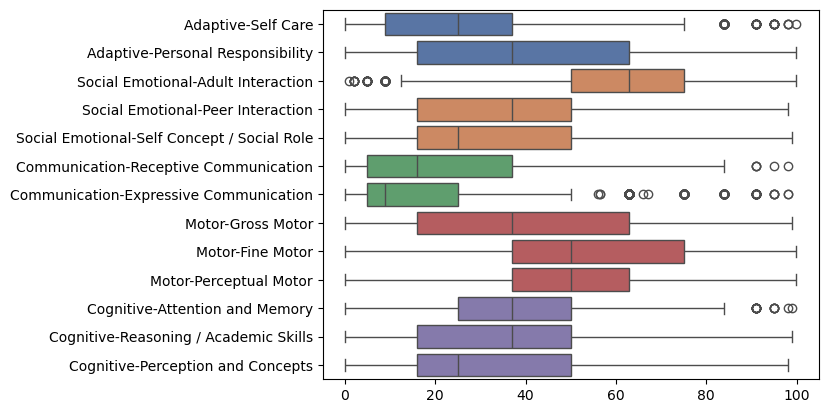

In [56]:
sns.boxplot(smid_df[subdomPR_col], orient='h', palette=subcolormap)

#### Scoring Group: **Top**

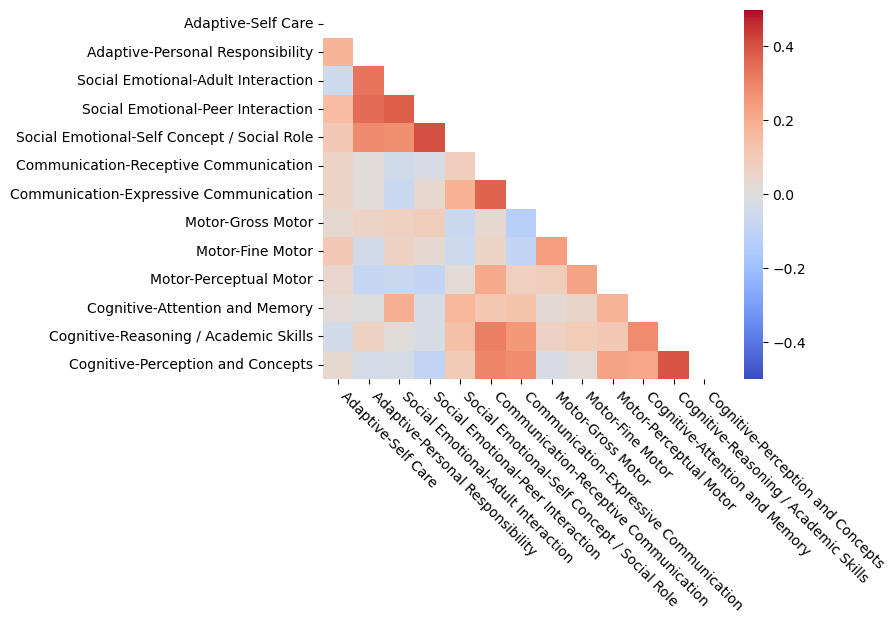

In [57]:
corr_mtx = stop_df[subdomPR_col].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=0.5, vmin=-0.5, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

<Axes: >

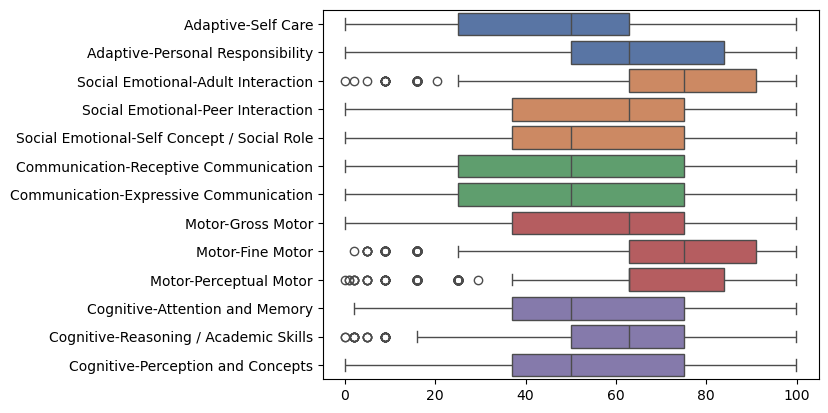

In [58]:
sns.boxplot(stop_df[subdomPR_col], orient='h', palette=subcolormap)

### 4. Does the child's age seem to impact their scoring?

In [70]:
sdomAGE_col = [col for col in columns if re.match(r'.*Testing Age', col)]
child_df['age_months'] = (child_df[sdomAGE_col].mean(axis=1).dt.days / 30.44).round(2)

domPR_col = [col for col in columns if re.match(r'.*Percentile Rank', col)]
domPR_agedf = child_df[['child_id'] + domPR_col + ['age_months']]

for dom in domains.keys():
    domPR_agedf = domPR_agedf.rename(columns = {f'{dom} Percentile Rank': f'{dom}'})

In [71]:
domPR_agedf = domPR_agedf.groupby('child_id').max()

In [137]:
domPR_agedf['age_group'] = pd.cut(
    domPR_agedf['age_months'], 
    bins=[0, 2, 12, 36], 
    labels=['Newborn','Infant','Toddler'])

In [138]:
domPR_agedf[list(domains.keys())].corr()

,Adaptive,Social-Emotional,Communication,Motor,Cognitive
Adaptive,1.000000,0.555225,0.463812,0.492640,0.475237
Social-Emotional,0.555225,1.000000,0.519299,0.461759,0.594271
Communication,0.463812,0.519299,1.000000,0.404886,0.652000
Motor,0.492640,0.461759,0.404886,1.000000,0.523688
Cognitive,0.475237,0.594271,0.652000,0.523688,1.000000


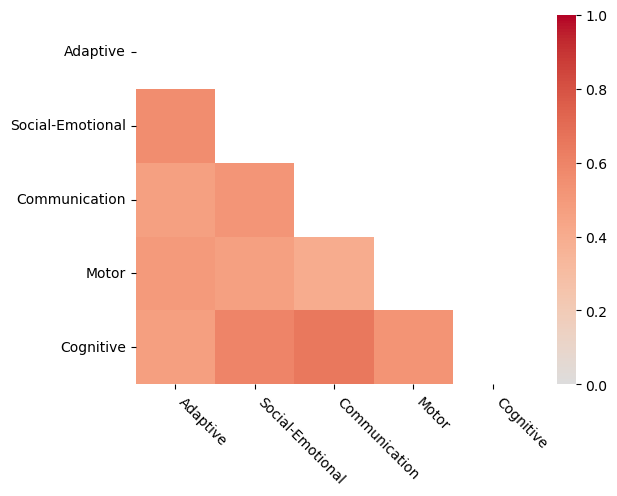

In [142]:
corr_mtx = domPR_agedf[list(domains.keys())].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=1, vmin=0, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

In [153]:
domPR_agedf.groupby('age_group')[list(domains.keys())].corr()

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/1178075896.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  domPR_agedf.groupby('age_group')[list(domains.keys())].corr()


Adaptive  Social-Emotional  Communication  \
age_group                                                               
Newborn   Adaptive          1.000000          0.307384       0.292826   
          Social-Emotional  0.307384          1.000000       0.592583   
          Communication     0.292826          0.592583       1.000000   
          Motor             0.268236          0.433596       0.414331   
          Cognitive         0.257154          0.569342       0.504684   
Infant    Adaptive          1.000000          0.363029       0.255944   
          Social-Emotional  0.363029          1.000000       0.498110   
          Communication     0.255944          0.498110       1.000000   
          Motor             0.382466          0.420865       0.532055   
          Cognitive         0.282880          0.616274       0.566780   
Toddler   Adaptive          1.000000          0.624256       0.480526   
          Social-Emotional  0.624256          1.000000       0.519574   
          Communication     0.480526          0.519574       1.000000   
          Motor             0.510789          0.500934       0.435335   
          Cognitive         0.513423          0.578598       0.631254   

                               Motor  Cognitive  
age_group                                        
Newborn   Adaptive          0.268236   0.257154  
          Social-Emotional  0.433596   0.569342  
          Communication     0.414331   0.504684  
          Motor             1.000000   0.489757  
          Cognitive         0.489757   1.000000  
Infant    Adaptive          0.382466   0.282880  
          Social-Emotional  0.420865   0.616274  
          Communication     0.532055   0.566780  
          Motor             1.000000   0.476641  
          Cognitive         0.476641   1.000000  
Toddler   Adaptive          0.510789   0.513423  
          Social-Emotional  0.500934   0.578598  
          Communication     0.435335   0.631254  
          Motor             1.000000   0.574784  
          Cognitive         0.574784   1.000000

In [164]:
domPR_agedf['age_group'].value_counts()

age_group
Toddler    14281
Infant      2879
Newborn      785
Name: count, dtype: int64

In [165]:
bottom_agedf = domPR_agedf.loc[domPR_agedf['age_group'] == 'Newborn']
mid_agedf = domPR_agedf.loc[domPR_agedf['age_group'] == 'Infant']
top_agedf = domPR_agedf.loc[domPR_agedf['age_group'] == 'Toddler']

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/2746340910.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_dom = domPR_agedf.groupby('age_group').mean()[list(domains.keys())]


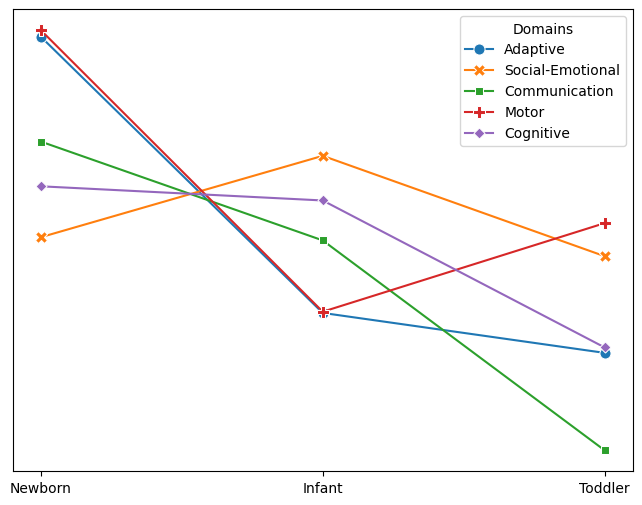

In [178]:
avg_dom = domPR_agedf.groupby('age_group').mean()[list(domains.keys())]

plt.figure(figsize=(8, 6))
parallel_plot = sns.lineplot(data=avg_dom,
                             dashes=False,
                             markers=True,
                             markersize=8)

plt.yticks([])
plt.legend(title='Domains',
           bbox_to_anchor=(1, 1), # Shift legend to the right
          )
plt.xlabel('')

plt.show()

#### Age Group: **Newborn**

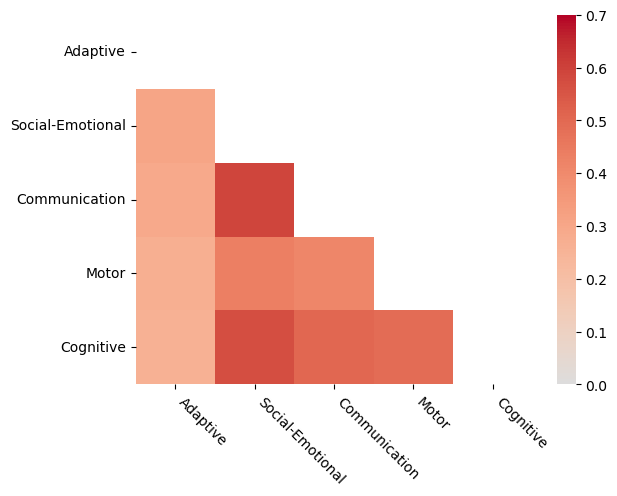

In [163]:
corr_mtx = bottom_agedf[list(domains.keys())].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=0.7, vmin=0, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

<Axes: >

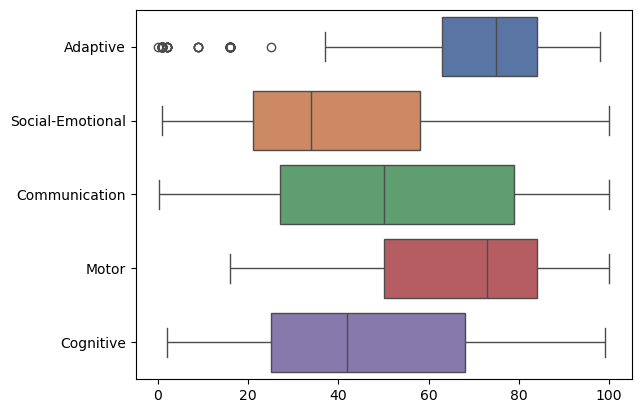

In [144]:
sns.boxplot(bottom_agedf[list(domains.keys())], orient='h', palette=colormap)

#### Age Group: **Infant**

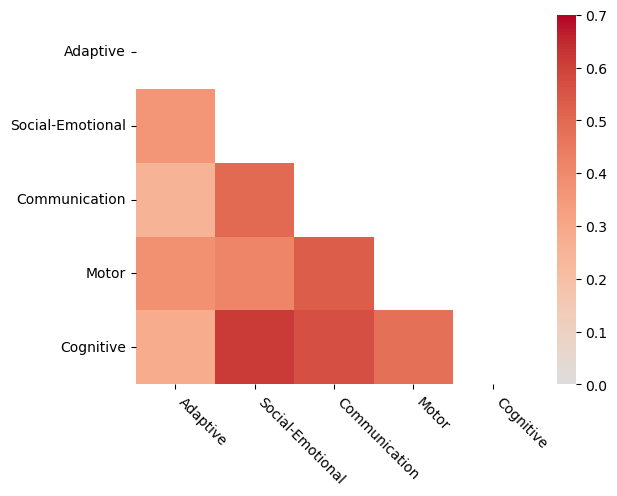

In [162]:
corr_mtx = mid_agedf[list(domains.keys())].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=0.7, vmin=0, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

<Axes: >

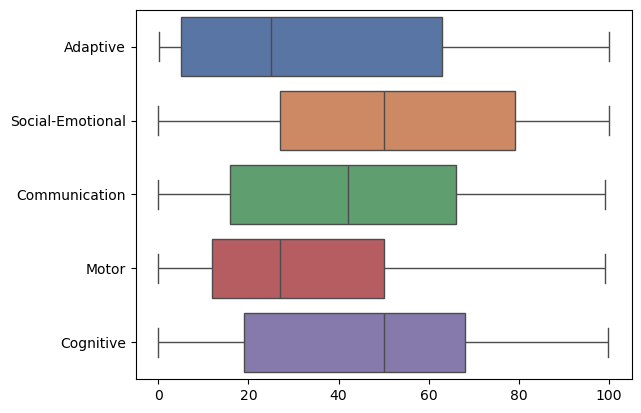

In [146]:
sns.boxplot(mid_agedf[list(domains.keys())], orient='h', palette=colormap)

#### Age Group: **Toddler**

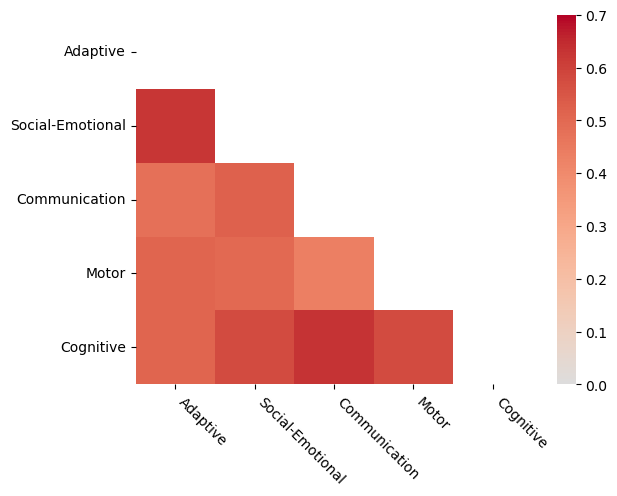

In [161]:
corr_mtx = top_agedf[list(domains.keys())].corr()
mask = np.triu(np.ones_like(corr_mtx, dtype=bool))

sns.heatmap(corr_mtx, mask=mask, cmap='coolwarm', vmax=0.7, vmin=0, center=0)
plt.xticks(rotation=-45, ha='left')

plt.show()

<Axes: >

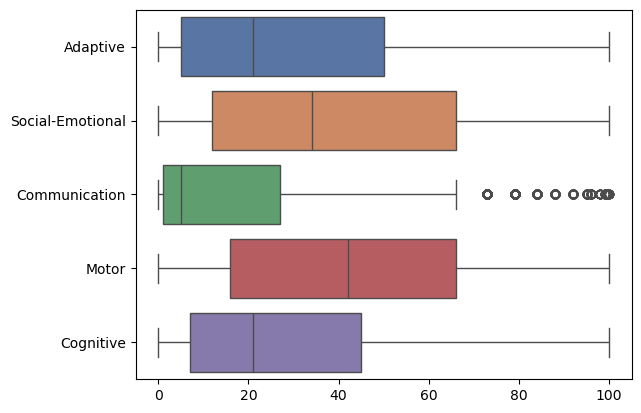

In [148]:
sns.boxplot(top_agedf[list(domains.keys())], orient='h', palette=colormap)

### 5. Eligibility is currently based on domains. A child would be considered eligible based on a 40% delay in one area or 25% delay in two areas, as determined by Development Quotient (DQ) scores. A DQ of 70 or less indicates a 40% delay, and a DQ between 71 and 78 indicates a 25% delay. If TEIS added an option for eligibility based on the total score on the BDI-3 total score (DQ score of 70 or less), are there any children who would have qualified that did not qualify based on the current method?

In [112]:
eligEval_df = child_df.loc[child_df['program_lbl'] == 'BDI-3 Eligibility Evaluation']

In [123]:
eligEval_df['old_eligible'] = ((eligEval_df['Adaptive Developmental Quotient'] <= 70) | 
                               (eligEval_df['Social-Emotional Developmental Quotient'] <= 70) | 
                               (eligEval_df['Communication Developmental Quotient'] <= 70) |
                               (eligEval_df['Motor Developmental Quotient'] <= 70) |
                               (eligEval_df['Cognitive Developmental Quotient'] <= 70) |
                               ((eligEval_df['Adaptive Developmental Quotient'] > 70) & (eligEval_df['Social-Emotional Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Adaptive Developmental Quotient'] > 70) & (eligEval_df['Communication Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Adaptive Developmental Quotient'] > 70) & (eligEval_df['Motor Developmental Quotient'] <= 78)) | 
                               ((eligEval_df['Adaptive Developmental Quotient'] > 70) & (eligEval_df['Cognitive Developmental Quotient'] <= 78)) | 
                               ((eligEval_df['Social-Emotional Developmental Quotient'] > 70) & (eligEval_df['Communication Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Social-Emotional Developmental Quotient'] > 70) & (eligEval_df['Motor Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Social-Emotional Developmental Quotient'] > 70) & (eligEval_df['Cognitive Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Communication Developmental Quotient'] > 70) & (eligEval_df['Motor Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Communication Developmental Quotient'] > 70) & (eligEval_df['Cognitive Developmental Quotient'] <= 78)) |
                               ((eligEval_df['Motor Developmental Quotient'] > 70) & (eligEval_df['Cognitive Developmental Quotient'] <= 78)))

eligEval_df.loc[~(eligEval_df['old_eligible']) & (eligEval_df['BDI-3 Total Developmental Quotient'] <= 70)]

/var/folders/6q/62m63jt13_79jxp668tbwsd80000gp/T/ipykernel_79396/2204873194.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eligEval_df['old_eligible'] = ((eligEval_df['Adaptive Developmental Quotient'] <= 70) |


,child_id,gender,DOB,location_sublvl1,contract_no,program_lbl,Adaptive Sum of Scaled Scores,Adaptive Developmental Quotient,Adaptive Percentile Rank,Adaptive 95% Confidence Interval,Adaptive RDI,Adaptive Z-Score,Adaptive T-Score,Adaptive NCE,Social-Emotional Sum of Scaled Scores,Social-Emotional Developmental Quotient,Social-Emotional Percentile Rank,Social-Emotional 95% Confidence Interval,Social-Emotional RDI,Social-Emotional Z-Score,Social-Emotional T-Score,Social-Emotional NCE,Communication Sum of Scaled Scores,Communication Developmental Quotient,Communication Percentile Rank,Communication 95% Confidence Interval,Communication RDI,Communication Z-Score,Communication T-Score,Communication NCE,Motor Sum of Scaled Scores,Motor Developmental Quotient,Motor Percentile Rank,Motor 95% Confidence Interval,Motor RDI,Motor Z-Score,Motor T-Score,Motor NCE,Cognitive Sum of Scaled Scores,Cognitive Developmental Quotient,Cognitive Percentile Rank,Cognitive 95% Confidence Interval,Cognitive RDI,Cognitive Z-Score,Cognitive T-Score,Cognitive NCE,BDI-3 Total Sum of Scaled Scores,BDI-3 Total Developmental Quotient,BDI-3 Total Percentile Rank,BDI-3 Total 90% Confidence Interval,BDI-3 Total 95% Confidence Interval,BDI-3 Total Z-Score,BDI-3 Total T-Score,BDI-3 Total NCE,Adaptive-Self Care Examiner,Adaptive-Self Care Date of Testing,Adaptive-Self Care RS,Adaptive-Self Care SS,Adaptive-Self Care PR,Adaptive-Self Care AE,Adaptive-Self Care RDI,Adaptive-Self Care CSS,Adaptive-Self Care CSS 90%,Adaptive-Self Care Z-Score,Adaptive-Self Care T-Score,Adaptive-Self Care NCE,Adaptive-Personal Responsibility Examiner,Adaptive-Personal Responsibility Date of Testing,Adaptive-Personal Responsibility RS,Adaptive-Personal Responsibility SS,Adaptive-Personal Responsibility PR,Adaptive-Personal Responsibility AE,Adaptive-Personal Responsibility RDI,Adaptive-Personal Responsibility CSS,Adaptive-Personal Responsibility CSS 90%,Adaptive-Personal Responsibility Z-Score,Adaptive-Personal Responsibility T-Score,Adaptive-Personal Responsibility NCE,Social Emotional-Adult Interaction Examiner,Social Emotional-Adult Interaction Date of Testing,Social Emotional-Adult Interaction RS,Social Emotional-Adult Interaction SS,Social Emotional-Adult Interaction PR,Social Emotional-Adult Interaction AE,Social Emotional-Adult Interaction RDI,Social Emotional-Adult Interaction CSS,Social Emotional-Adult Interaction CSS 90%,Social Emotional-Adult Interaction Z-Score,Social Emotional-Adult Interaction T-Score,Social Emotional-Adult Interaction NCE,Social Emotional-Peer Interaction Examiner,Social Emotional-Peer Interaction Date of Testing,Social Emotional-Peer Interaction RS,Social Emotional-Peer Interaction SS,Social Emotional-Peer Interaction PR,Social Emotional-Peer Interaction AE,Social Emotional-Peer Interaction RDI,Social Emotional-Peer Interaction CSS,Social Emotional-Peer Interaction CSS 90%,Social Emotional-Peer Interaction Z-Score,Social Emotional-Peer Interaction T-Score,Social Emotional-Peer Interaction NCE,Social Emotional-Self Concept / Social Role Examiner,Social Emotional-Self Concept / Social Role Date of Testing,Social Emotional-Self Concept / Social Role RS,Social Emotional-Self Concept / Social Role SS,Social Emotional-Self Concept / Social Role PR,Social Emotional-Self Concept / Social Role AE,Social Emotional-Self Concept / Social Role RDI,Social Emotional-Self Concept / Social Role CSS,Social Emotional-Self Concept / Social Role CSS 90%,Social Emotional-Self Concept / Social Role Z-Score,Social Emotional-Self Concept / Social Role T-Score,Social Emotional-Self Concept / Social Role NCE,Communication-Receptive Communication Examiner,Communication-Receptive Communication Date of Testing,Communication-Receptive Communication RS,Communication-Receptive Communication SS,Communication-Receptive Communication PR,Communication-Receptive Communication AE,Communication-Receptive Communication RDI,Communication-Receptive Communication CSS,Communication-Receptive Communic

### 6. Is there any difference in scoring noted based on evaluation type?

### 7. Is there any notable pattern of scoring by region? Note: TEIS contracts with three agencies for evaluations (one per grand region) as follows:  
* East TN, First TN and Southeast
* Greater Nashville, Upper Cumberland, and South Central
* Northwest, Southwest, and Memphis Delta

### 8. Is there any notable pattern of scoring by evaluator?

### Stretch Goal:
* Investigate the records that are missing ID values. Have they gotten better or worse over time? Are there repeat offenders?
* As noted above, this evaluation may be repeated every 4 months. How often did it occur that a child was assessed multiple times in a time period of less than 120 days. Has this gotten better or worse over time?